## Learning targets

1. Apply one geometric decision to an image–mask pair.
2. Resize RGB pixels and class-index masks with the right interpolation.
3. Identify image, feature-map, and logit shapes in a dense-prediction model.

In [1]:
# Setup — install only on Colab; local execution uses the repository .venv.
import sys
if "google.colab" in sys.modules:
    %pip install -q torch torchvision matplotlib numpy

In [2]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import OxfordIIITPet
from torchvision.models.segmentation import LRASPP_MobileNet_V3_Large_Weights, lraspp_mobilenet_v3_large
from torchvision.transforms import InterpolationMode
from torchvision.transforms import functional as TF

SEED = 17
IMAGE_SIZE = (128, 128)
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]
random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch={torch.__version__} | torchvision={torchvision.__version__} | device={device}")

torch=2.11.0+cpu | torchvision=0.26.0+cpu | device=cpu


## 1. Load a fixed set of paired examples

The photograph and trimap describe the same coordinates. We use four deterministic examples for preprocessing and a small batch for the forward pass—there is **no training** in this session.

In [3]:
# Set OXFORD_PET_ROOT to a pre-cached data directory if your class has one.
DATA_ROOT = Path(os.environ.get("OXFORD_PET_ROOT", "data"))
raw_dataset = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="segmentation", download=True)
indices = torch.randperm(len(raw_dataset), generator=torch.Generator().manual_seed(SEED))[:8].tolist()
print(f"dataset pairs={len(raw_dataset)} | fixed teaching indices={indices}")

100%|██████████| 792M/792M [00:21<00:00, 37.6MB/s]
100%|██████████| 19.2M/19.2M [00:00<00:00, 19.4MB/s]


dataset pairs=3680 | fixed teaching indices=[2479, 1638, 733, 859, 670, 249, 2390, 1408]


Oxford-IIIT Pet trimaps use raw labels `1 = pet`, `2 = background`, and `3 = boundary`. The course convention is `1 = pet`, `0 = background`, and `255 = ignore boundary`.

In [4]:
def remap_trimap(mask):
    """Convert one raw PIL trimap to class IDs for a two-class loss."""
    raw = torch.as_tensor(np.asarray(mask, dtype=np.uint8), dtype=torch.int64)
    remapped = torch.full_like(raw, 255)
    remapped[raw == 1] = 1
    remapped[raw == 2] = 0
    assert set(torch.unique(remapped).tolist()) <= {0, 1, 255}
    return remapped

raw_image, raw_trimap = raw_dataset[indices[0]]
print("raw trimap IDs:", np.unique(np.asarray(raw_trimap)).tolist())
print("remapped IDs:", torch.unique(remap_trimap(raw_trimap)).tolist())

raw trimap IDs: [1, 2, 3]
remapped IDs: [0, 1, 255]


/tmp/ipykernel_770/1516817490.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  raw = torch.as_tensor(np.asarray(mask, dtype=np.uint8), dtype=torch.int64)


## 2. Build synchronized preprocessing

Resize the RGB image with bilinear interpolation, but resize the categorical mask with nearest-neighbor interpolation. Then make exactly one flip decision and apply it to both objects.

In [5]:
# TODO: your code here
def paired_transform(image, raw_mask, training=False, force_flip=None):
    # Continuous RGB values may be interpolated; categorical class IDs may not.
    image = TF.resize(
        image,
        IMAGE_SIZE,
        interpolation=InterpolationMode.BILINEAR,
        antialias=True,
    )
    raw_mask = TF.resize(
        raw_mask,
        IMAGE_SIZE,
        interpolation=InterpolationMode.NEAREST,
    )

    # One shared Boolean protects correspondence between image coordinates and mask coordinates.
    do_flip = (
        force_flip
        if force_flip is not None
        else (training and random.random() < 0.5)
    )

    if do_flip:
        image = TF.hflip(image)
        raw_mask = TF.hflip(raw_mask)

    image = TF.normalize(TF.to_tensor(image), mean=MEAN, std=STD)
    mask = remap_trimap(raw_mask)

    assert set(torch.unique(mask).tolist()) <= {0, 1, 255}
    return image, mask

Success: forced flip keeps allowed remapped IDs: [0, 1, 255]


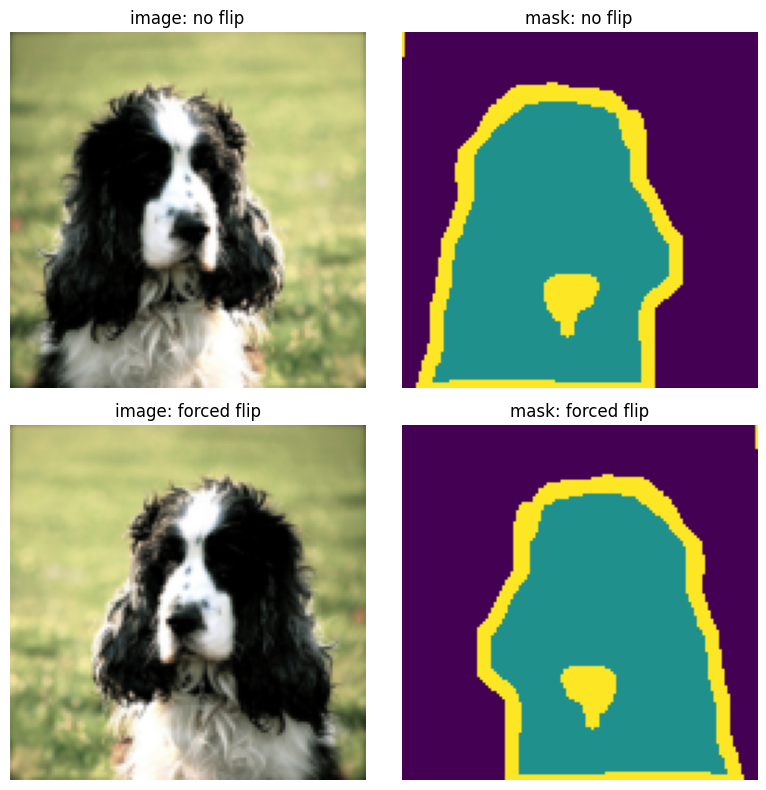

In [6]:
def image_for_display(image_tensor):
    mean = torch.tensor(MEAN)[:, None, None]
    std = torch.tensor(STD)[:, None, None]
    return (image_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

normal_image, normal_mask = paired_transform(raw_image, raw_trimap, force_flip=False)
flipped_image, flipped_mask = paired_transform(raw_image, raw_trimap, force_flip=True)
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for ax, panel, title, cmap in [
    (axes[0, 0], image_for_display(normal_image), "image: no flip", None),
    (axes[0, 1], normal_mask, "mask: no flip", "viridis"),
    (axes[1, 0], image_for_display(flipped_image), "image: forced flip", None),
    (axes[1, 1], flipped_mask, "mask: forced flip", "viridis"),
]:
    ax.imshow(panel, cmap=cmap, vmin=0 if cmap else None, vmax=2 if cmap else None)
    ax.set_title(title); ax.axis("off")
plt.tight_layout()
assert set(torch.unique(flipped_mask).tolist()) <= {0, 1, 255}
print("Success: forced flip keeps allowed remapped IDs:", torch.unique(flipped_mask).tolist())

## 3. Audit a small batch

The dataset wrapper applies the same pair transform to each example. This is the contract expected by a segmentation loss: images are floating point `[N, 3, H, W]`; masks are integer class IDs `[N, H, W]`.

In [7]:
class PetSubset(Dataset):
    def __init__(self, base_dataset, subset_indices):
        self.base_dataset, self.indices = base_dataset, list(subset_indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, item):
        image, mask = self.base_dataset[self.indices[item]]
        return paired_transform(image, mask, training=False)

loader = DataLoader(PetSubset(raw_dataset, indices), batch_size=4, shuffle=False, num_workers=0)
images, masks = next(iter(loader))
print(f"images: shape={tuple(images.shape)}, dtype={images.dtype}")
print(f"masks:  shape={tuple(masks.shape)}, dtype={masks.dtype}, values={torch.unique(masks).tolist()}")
assert images.shape == (4, 3, 128, 128) and images.dtype == torch.float32
assert masks.shape == (4, 128, 128) and masks.dtype == torch.int64

images: shape=(4, 3, 128, 128), dtype=torch.float32
masks:  shape=(4, 128, 128), dtype=torch.int64, values=[0, 1, 255]


## 4. Inspect a pretrained forward pass

LR-ASPP is a lightweight pretrained segmentation model. We do not train or alter it here. We only inspect how a ready-made dense predictor maps a batch of images to one class-score vector at every pixel.

In [8]:
weights = LRASPP_MobileNet_V3_Large_Weights.DEFAULT
model = lraspp_mobilenet_v3_large(weights=weights).to(device).eval()
with torch.no_grad():
    output = model(images.to(device))["out"].cpu()
print(f"input batch:   {tuple(images.shape)}")
print(f"output logits: {tuple(output.shape)}")
print("Logits are float scores, so they are not a final class-index mask.")
assert output.shape[0] == images.shape[0]
assert output.shape[2:] == images.shape[2:]
assert output.dtype.is_floating_point

Downloading: "https://download.pytorch.org/models/lraspp_mobilenet_v3_large-d234d4ea.pth" to /root/.cache/torch/hub/checkpoints/lraspp_mobilenet_v3_large-d234d4ea.pth


100%|██████████| 12.5M/12.5M [00:00<00:00, 96.1MB/s]


input batch:   (4, 3, 128, 128)
output logits: (4, 21, 128, 128)
Logits are float scores, so they are not a final class-index mask.


argmax prediction: (4, 128, 128), dtype=torch.int64


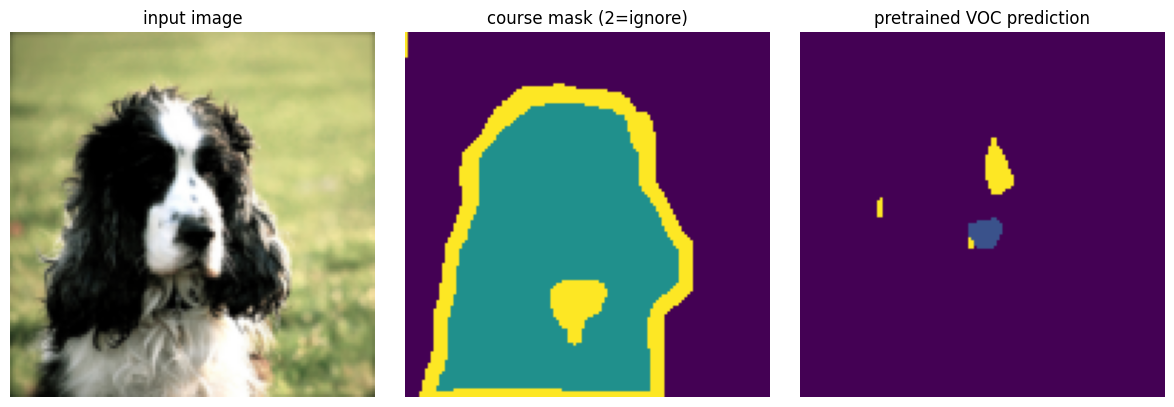

In [9]:
prediction = output.argmax(dim=1)
print(f"argmax prediction: {tuple(prediction.shape)}, dtype={prediction.dtype}")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image_for_display(images[0])); axes[0].set_title("input image")
axes[1].imshow(masks[0], cmap="viridis", vmin=0, vmax=2); axes[1].set_title("course mask (2=ignore)")
axes[2].imshow(prediction[0], cmap="viridis"); axes[2].set_title("pretrained VOC prediction")
for ax in axes: ax.axis("off")
plt.tight_layout()

## Wrap-up

You protected image–mask alignment through resize and flip, verified the class-ID mask contract, and observed that a segmentation model returns logits with one class-score channel per class at every image location.

Discuss with a partner: why can a model use smaller internal maps for context yet return logits on the original 128×128 grid?